In [1]:
import pandas as pd
import numpy as np
import os
import shap
import matplotlib
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
FPSIZE = 4096
TOP_N_PER_TARGET = 50

In [3]:
df = pd.read_csv('../nr_ic_merged.csv')

In [4]:
# Keep only valid SMILES
def smiles_to_mol(s):
    if pd.isna(s) or str(s).lower() == 'nan':
        return None
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None

df['mol'] = df['Smiles'].map(smiles_to_mol)
df = df[df['mol'].notna()].copy()

In [5]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FPSIZE)


def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((FPSIZE,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


df['fp'] = df['mol'].map(mol_to_fp)

In [6]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8615541fc0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8615542030>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7f86155420a0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8615542110>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7f8615542180>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7f86151e8890>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7f86151e8900>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7f86151e8970>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7f86151e89e0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
target_encoded = encoder.fit_transform(df[['Target']])
target_names = encoder.categories_[0]

# Store each one-hot vector as a list
df['target_encoded'] = target_encoded.tolist()

In [8]:
import numpy as np

# Convert fp arrays to tuples so they are hashable
df['fp_tuple'] = df['fp'].apply(lambda x: tuple(x))

# Group by fingerprint and OR-combine their one-hot target vectors
grouped = df.groupby('fp_tuple')['target_encoded'].apply(
    lambda rows: np.any(np.vstack(rows.values), axis=0).astype(int)
)

df_agg = grouped.reset_index()

# Convert fp back to numpy array
df_agg['fp'] = df_agg['fp_tuple'].apply(lambda x: np.array(x))

# Rename the aggregated target vector
df_agg = df_agg.rename(columns={'target_encoded': 'target'})

# Remove helper column
df_agg = df_agg.drop(columns=['fp_tuple'])

In [9]:
x = np.vstack(df_agg['fp'].values)
y = np.vstack(df_agg['target'].values)

In [10]:
print(f"Data Prepared. Shape: {x.shape}")

Data Prepared. Shape: (7207, 4096)


In [11]:
n_targets = y.shape[1]
all_selected_features = set()
feature_importance_matrix = [] # Store for visualization

print(f"\nStarting Feature Selection for {n_targets} targets independently...")

for i in range(n_targets):
    checkpoint_file = f"importance_target_{target_names[i]}.npy"

    if os.path.exists(checkpoint_file):
        print(f"\n>>> [Target {target_names[i]}] Found checkpoint '{checkpoint_file}'. Loading...")
        target_importance = np.load(checkpoint_file)
    else:
        print(f"\n>>> [Target {target_names[i]}] Calculating SHAP from scratch...")

        y_target = y[:, i]
        rf_target = RandomForestClassifier(n_estimators=100, max_depth=None, n_jobs=-1, random_state=42)
        rf_target.fit(x, y_target)

        # Sample for SHAP
        sample_size = min(2500, x.shape[0])
        background_idx = np.random.choice(x.shape[0], size=sample_size, replace=False)
        X_sample = x[background_idx]

        # Small background set (SHAP best practice)
        background = x[np.random.choice(x.shape[0], size=200, replace=False)]

        # Unified SHAP API supporting model_output="probability"
        explainer = shap.Explainer(
            rf_target,
            background,
            model_output="probability"
        )

        shap_out = explainer(X_sample)

        # shap_out.values: (n_samples, n_features)
        vals = shap_out.values

        # Fix shape:
        if vals.ndim == 3:
            if vals.shape[2] == 1:
                vals = vals[:, :, 0]
            else:
                vals = vals[:, :, 1]   # positive class

        vals = np.abs(vals)

        # Importance per feature
        target_importance = vals.mean(axis=0)

        # Force 1-D exactly
        target_importance = target_importance.ravel()
        np.save(checkpoint_file, target_importance)
        print(f"    Saved importance to {checkpoint_file}")

    # Store for visualization later
    feature_importance_matrix.append(target_importance)

    # Selection Logic
    sorted_idx = np.argsort(target_importance)[::-1]
    top_n_idx = sorted_idx[:TOP_N_PER_TARGET]
    all_selected_features.update(top_n_idx)

final_selected_indices = sorted(list(all_selected_features))
print(f"\n[DONE] Total unique features selected: {len(final_selected_indices)}")


Starting Feature Selection for 6 targets independently...

>>> [Target ar] Found checkpoint 'importance_target_ar.npy'. Loading...

>>> [Target era] Found checkpoint 'importance_target_era.npy'. Loading...

>>> [Target erb] Found checkpoint 'importance_target_erb.npy'. Loading...

>>> [Target gr] Found checkpoint 'importance_target_gr.npy'. Loading...

>>> [Target mr] Found checkpoint 'importance_target_mr.npy'. Loading...

>>> [Target pr] Found checkpoint 'importance_target_pr.npy'. Loading...

[DONE] Total unique features selected: 189


Training Final OneVsRest Model on selected features...
Generating ROC Curves...


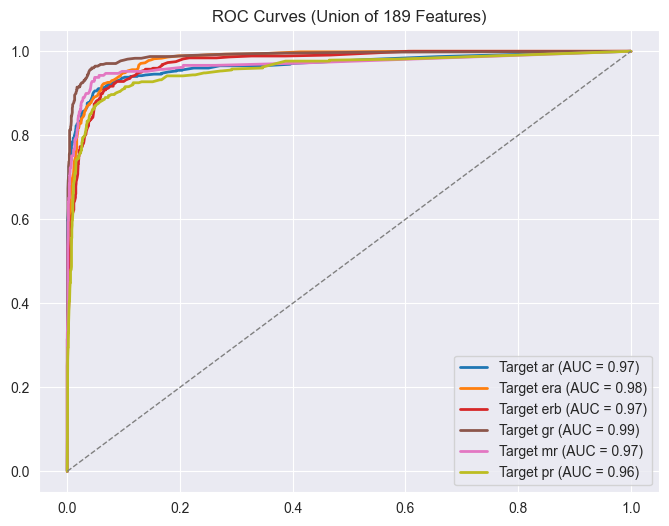

In [12]:
if len(final_selected_indices) == 0:
    print("Warning: No features selected! Using all features.")
    X_selected = x
else:
    # Filter the original X matrix to keep only the union of important features
    X_selected = x[:, final_selected_indices]

# Split Data
x_train, x_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42
)

print("Training Final OneVsRest Model on selected features...")
model = OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=100,
            max_depth=None,
            random_state=42,
            n_jobs=-1
))
model.fit(x_train, y_train)

# Evaluation
y_pred_prob = model.predict_proba(x_test)
y_pred_prob_matrix = np.column_stack(y_pred_prob).T

print("Generating ROC Curves...")
plt.figure(figsize=(8, 6))
cmap = matplotlib.colormaps.get_cmap('tab10')

for i in range(n_targets):
    if len(np.unique(y_test[:, i])) > 1:
        auc_score = roc_auc_score(y_test[:, i], y_pred_prob_matrix[:, i])
        fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_prob_matrix[:, i])
        color = cmap(i / n_targets)
        plt.plot(fpr, tpr, color=color, lw=2, label=f"Target {target_names[i]} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.title(f"ROC Curves (Union of {len(final_selected_indices)} Features)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Generating individual plots for 6 targets...


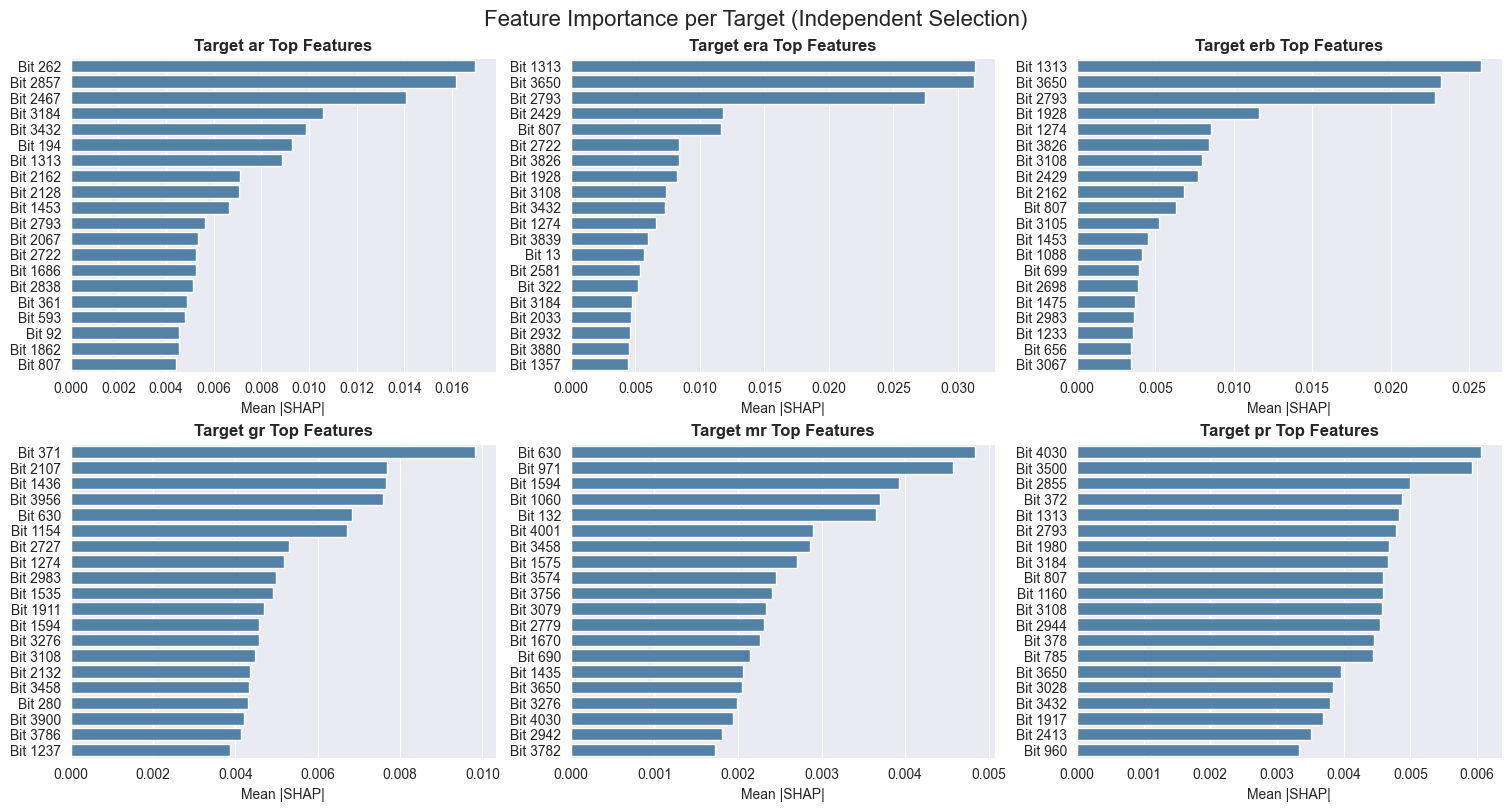

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# CONFIGURATION
TOP_N = 20  # How many top bits to show per target
COLS = 3    # How many charts per row
n_targets = len(feature_importance_matrix)
rows = math.ceil(n_targets / COLS)

# Set up the figure
fig, axes = plt.subplots(rows, COLS, figsize=(5 * COLS, 4 * rows), constrained_layout=True)
axes = axes.flatten() # Flatten 2D grid to 1D array for easy looping

print(f"Generating individual plots for {n_targets} targets...")

for i in range(n_targets):
    ax = axes[i]

    # Get importance for specific target
    imp = feature_importance_matrix[i]

    # Sort and get Top N indices for THIS target specifically
    # indices are [0, 1, 2... 4095]
    top_indices = np.argsort(imp)[::-1][:TOP_N]
    top_values = imp[top_indices]

    # Create labels like "Bit 1024", "Bit 512"
    labels = [f"Bit {idx}" for idx in top_indices]

    # Plot Horizontal Bar Chart
    sns.barplot(x=top_values, y=labels, ax=ax, color='steelblue')

    ax.set_title(f"Target {target_names[i]} Top Features", fontsize=12, fontweight='bold')
    ax.set_xlabel("Mean |SHAP|")

# Turn off any empty subplots if targets < rows*cols
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f"Feature Importance per Target (Independent Selection)", fontsize=16)
plt.savefig('shap_target_grid.png', dpi=300)
plt.show()

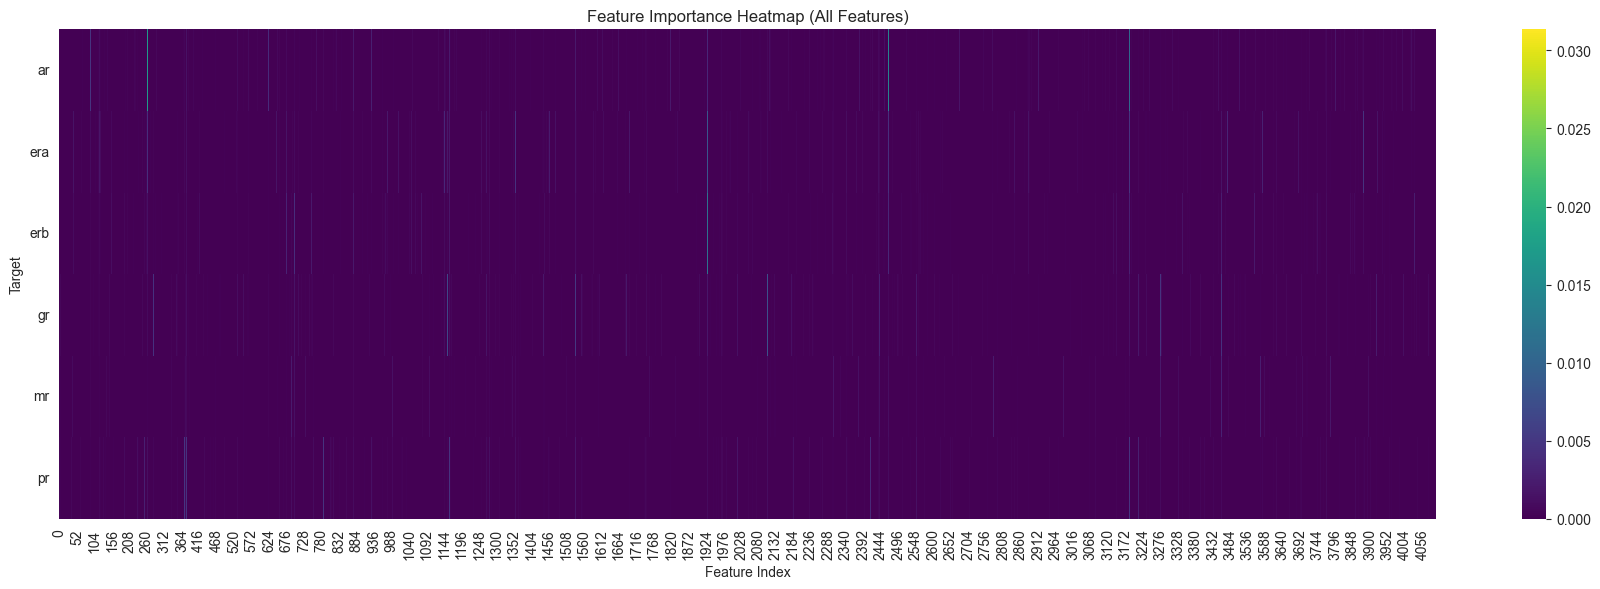

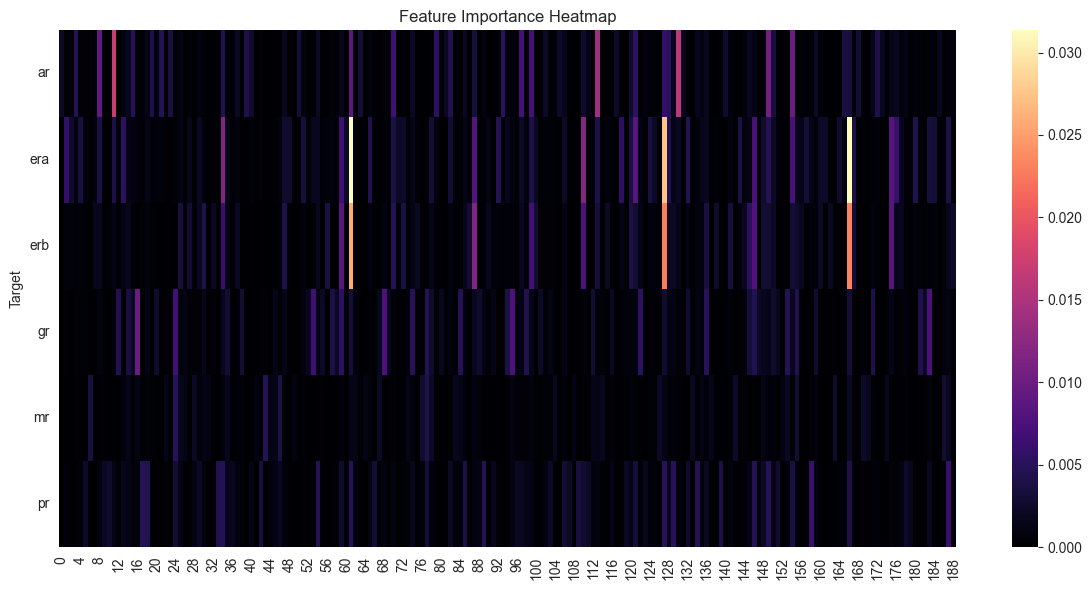

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert list → matrix
importance_matrix = np.vstack(feature_importance_matrix)  # shape: (n_targets, n_features)

plt.figure(figsize=(18, 6))
sns.heatmap(
    importance_matrix,
    cmap="viridis",
    cbar=True
)
plt.yticks(ticks=np.arange(len(target_names)) + 0.5, labels=target_names, rotation=0)
plt.title("Feature Importance Heatmap (All Features)")
plt.xlabel("Feature Index")
plt.ylabel("Target")
plt.tight_layout()
plt.show()

selected_matrix = importance_matrix[:, final_selected_indices]

plt.figure(figsize=(12, 6))
sns.heatmap(
    selected_matrix,
    cmap="magma",
    cbar=True
)
plt.yticks(ticks=np.arange(len(target_names)) + 0.5, labels=target_names, rotation=0)
plt.title("Feature Importance Heatmap")
plt.ylabel("Target")
plt.tight_layout()
plt.show()
